##### For the human survey results

In [1]:
#importing the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error)

In [2]:
#loading the data

df = pd.read_csv('survey_results.csv')
df.head(5)

,User ID,ID,Data Provider,Project Name,Consumer Team,Consumer Name,Consumer Description,Variation Type,Variation Value,Purpose,AI Final Decision,Human Expert: Seniority,Human Expert: Hastiness (1: Very Hasty | 7: Very Formal),Human Expert: Meaning Preservation (1: Very Different | 7: Very Similar),Time on Question (seconds),Total Elapsed Time (seconds)
0,user_777,3e6df138892d6908a28f951eec68f5cc902c778c4db63e...,Marketing Campaigns,Policy Customization Algorithm,contracts,Custom Policy Advisor,Enhances the customer interaction experience b...,combined,"junior analyst + very hasty (typos, shorthand,...",hey can i get access to the marketing campaign...,Reject,Senior Manager,7,7,7.27,7.38
1,user_777,569aece891f2a8d3ee80645eba515c0af80c714bb4036f...,Payments,AI-driven Customer Service Enhancements,enabling-team,AI Service Enhancer,Uses AI to anticipate and resolve customer iss...,combined,executive/CEO + very formal (precise legal-sty...,In order to enhance the experience of our cust...,Reject,Senior Manager,7,7,32.11,39.49
2,user_777,bd7b9717630b7177aecf10a02c0dcbdb02b9d42dce0a52...,Order Lines,Logistics Demand Forecasting,logistics,Demand Forecasting System,Enhances stock and resource allocation by pred...,combined,executive/CEO + neutral (standard professional...,The Logistics team intends to access the 'Orde...,Accept,Senior Manager,7,7,87.12,126.62
3,user_777,ab19af49dfaf765c37a9852fbfac73328cdbc036ac141b...,Actor,Automatic Claim Processing,claims--benefit,Automated Claims Handler,Streamlines the claim verification process by ...,combined,senior manager + neutral (standard professiona...,Our application needs access to actors' contac...,Accept,Senior Manager,7,7,147.18,273.80
4,user_777,5fbf5126f2e1e7a0840e4230d7079b429f84ebf0d88b5e...,Products,Product Performance Metrics,marketing,Product Success Evaluator,Analyzes product performance metrics to enhanc...,combined,"executive/CEO + very hasty (typos, shorthand, ...",need data on which items r hot reviews n retur...,Reject,Junior Analyst,1,1,80.08,353.88


In [3]:
#the information of the survey df
print(df.head())
print(df.shape)

    User ID                                                 ID  \
0  user_777  3e6df138892d6908a28f951eec68f5cc902c778c4db63e...   
1  user_777  569aece891f2a8d3ee80645eba515c0af80c714bb4036f...   
2  user_777  bd7b9717630b7177aecf10a02c0dcbdb02b9d42dce0a52...   
3  user_777  ab19af49dfaf765c37a9852fbfac73328cdbc036ac141b...   
4  user_777  5fbf5126f2e1e7a0840e4230d7079b429f84ebf0d88b5e...   

         Data Provider                             Project Name  \
0  Marketing Campaigns           Policy Customization Algorithm   
1             Payments  AI-driven Customer Service Enhancements   
2          Order Lines             Logistics Demand Forecasting   
3                Actor               Automatic Claim Processing   
4             Products              Product Performance Metrics   

     Consumer Team              Consumer Name  \
0        contracts      Custom Policy Advisor   
1    enabling-team        AI Service Enhancer   
2        logistics  Demand Forecasting System   
3  c

In [4]:
#seperating the original and the modified (combined) requests

original_requests = df[df["Variation Type"] == "none"].copy()

modified_requests = df[df["Variation Type"] == "combined"].copy()


print(f"Total survey responses: {len(df)}") 
print(f"Modified request responses: {len(modified_requests)}") 
print(f"Original request responses: {len(original_requests)}") 
print(f"Number of participants: {df['User ID'].nunique()}")

Total survey responses: 250
Modified request responses: 232
Original request responses: 18
Number of participants: 5


In [5]:
#renaming the columns

df = df.rename(columns={
    "Human Expert: Seniority": "Human Seniority",
    "Human Expert: Hastiness (1: Very Hasty | 7: Very Formal)": "Human Hastiness",
    "Human Expert: Meaning Preservation (1: Very Different | 7: Very Similar)": "Meaning Preservation"
})

In [6]:
#extracting the combined dimensions

modified_requests["Seniority"] = (modified_requests["Variation Value"]
    .str.extract(r"^(intern|junior analyst|senior manager|executive/CEO)",expand=False)
    .replace({
        "intern": "Intern",
        "junior analyst": "Junior Analyst",
        "senior manager": "Senior Manager",
        "executive/CEO": "Executive/CEO"
    })
)


modified_requests["Hastiness"] = (modified_requests["Variation Value"]
.str.extract(
    r"\+\s*(very hasty|neutral|very formal)",
    expand=False
)
.replace({
    "very hasty": "Very Hasty",
    "neutral": "Neutral",
    "very formal": "Very Formal"
})
)


#checking it 
display(modified_requests["Seniority"].value_counts())
display(modified_requests["Hastiness"].value_counts())

Seniority
Executive/CEO     72
Intern            61
Junior Analyst    54
Senior Manager    45
Name: count, dtype: int64

Hastiness
Very Hasty     80
Neutral        78
Very Formal    74
Name: count, dtype: int64

In [7]:
#convering the meaning preservation (for the ones that original to 0)

modified_requests = modified_requests.rename(columns={
    "Human Expert: Meaning Preservation (1: Very Different | 7: Very Similar)": "Meaning Preservation"
})
modified_requests["Meaning Preservation"] = pd.to_numeric(modified_requests["Meaning Preservation"],errors="coerce")

In [8]:
#making the following summary table 

meaning_summary = pd.DataFrame({
    "Metric": [
        "Number of ratings",
        "Mean",
        "Median",
        "Standard deviation",
        "Minimum",
        "Maximum",
        "Ratings of 5 or higher (%)",
        "Ratings of 6 or higher (%)"
    ],
    "Value": [
        modified_requests["Meaning Preservation"].count(),
        round(modified_requests["Meaning Preservation"].mean(), 2),
        round(modified_requests["Meaning Preservation"].median(), 2),
        round(modified_requests["Meaning Preservation"].std(), 2),
        modified_requests["Meaning Preservation"].min(),
        modified_requests["Meaning Preservation"].max(),
        round((modified_requests["Meaning Preservation"] >= 5).mean() * 100,2),
        round((modified_requests["Meaning Preservation"] >= 6).mean() * 100,2)
    ]
})

display(meaning_summary)

,Metric,Value
0,Number of ratings,232.00
1,Mean,5.26
2,Median,6.00
3,Standard deviation,1.61
4,Minimum,1.00
5,Maximum,7.00
6,Ratings of 5 or higher (%),71.55
7,Ratings of 6 or higher (%),54.31


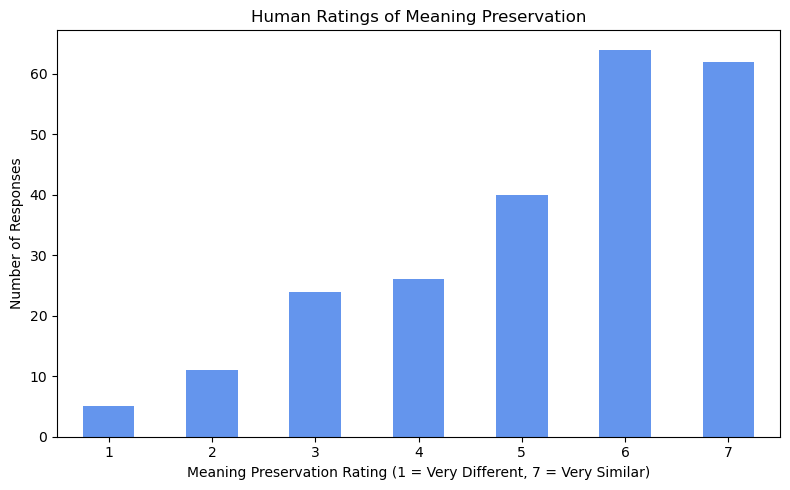

In [9]:
#plotting the meaning preservation

meaning_counts = (modified_requests["Meaning Preservation"].value_counts().sort_index())

plt.figure(figsize=(8, 5))
meaning_counts.plot(kind="bar",color = "cornflowerblue")

plt.xlabel("Meaning Preservation Rating (1 = Very Different, 7 = Very Similar)")
plt.ylabel("Number of Responses")
plt.title("Human Ratings of Meaning Preservation")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [10]:

#creating the intended scores for each seniority prompt
hastiness_scores = {"Very Hasty": 1,"Neutral": 4,"Very Formal": 7}
modified_requests["Intended Hastiness Score"] = (modified_requests["Hastiness"].map(hastiness_scores))


In [11]:
modified_requests = modified_requests.rename(columns={"Human Expert: Hastiness (1: Very Hasty | 7: Very Formal)":"Human Hastiness"})

hastiness_summary = (
    modified_requests
    .groupby("Hastiness")
    .agg(
        Number_of_Ratings=("Human Hastiness", "count"),
        Mean_Rating=("Human Hastiness", "mean"),
        Median_Rating=("Human Hastiness", "median"),
        Standard_Deviation=("Human Hastiness", "std")
    )
    .reset_index()
)

hastiness_summary[["Mean_Rating", "Median_Rating", "Standard_Deviation"]] = (
    hastiness_summary[["Mean_Rating", "Median_Rating", "Standard_Deviation"]].round(2))

display(hastiness_summary)

,Hastiness,Number_of_Ratings,Mean_Rating,Median_Rating,Standard_Deviation
0,Neutral,78,5.27,5.0,1.17
1,Very Formal,74,6.30,7.0,0.95
2,Very Hasty,80,1.76,1.0,1.15


In [12]:
#making sure both columns are numeric

#removing rows with missing scores
hastiness_evaluation = modified_requests.dropna(subset=["Human Hastiness", "Intended Hastiness Score"]).copy()

#calculating the difference between the human and intended ratings
hastiness_evaluation["Hastiness Difference"] = abs(hastiness_evaluation["Human Hastiness"]- hastiness_evaluation["Intended Hastiness Score"])

#calculating agreement
exact_hastiness_agreement = (hastiness_evaluation["Hastiness Difference"] == 0).mean() * 100

within_one_hastiness_agreement = (hastiness_evaluation["Hastiness Difference"] <= 1).mean() * 100

#calculating mean absolute error
hastiness_mae = mean_absolute_error(hastiness_evaluation["Intended Hastiness Score"],hastiness_evaluation["Human Hastiness"])

print(f"Number of valid ratings: {len(hastiness_evaluation)}")
print(f"Exact hastiness agreement: {exact_hastiness_agreement:.2f}%")
print(f"Agreement within one scale point: "f"{within_one_hastiness_agreement:.2f}%")
print(f"Mean absolute error: {hastiness_mae:.2f}")


Number of valid ratings: 232
Exact hastiness agreement: 43.97%
Agreement within one scale point: 71.98%
Mean absolute error: 0.96


In [13]:
#plotting the distribution selected from the students

hastiness_distribution = pd.crosstab(
    modified_requests["Hastiness"],
    modified_requests["Human Hastiness"]
)

hastiness_distribution = hastiness_distribution.reindex(["Very Hasty", "Neutral", "Very Formal"])

display(hastiness_distribution)


Human Hastiness,1,2,3,4,5,6,7
Hastiness,,,,,,,
Very Hasty,45,19,11,3,0,1,1
Neutral,0,1,3,16,26,18,14
Very Formal,0,1,0,0,15,17,41


<Figure size 1000x600 with 0 Axes>

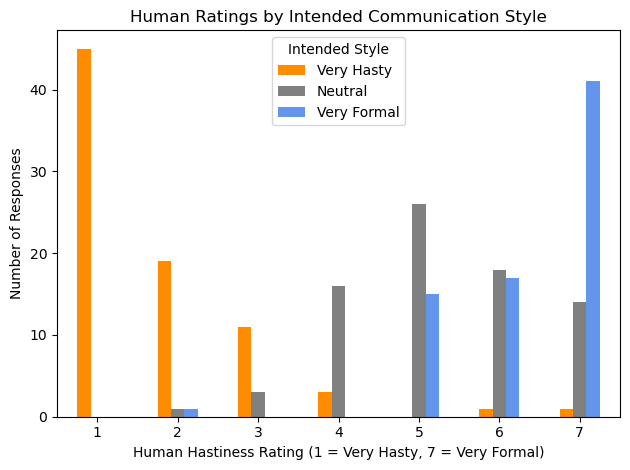

In [14]:
plt.figure(figsize=(10, 6))

hastiness_distribution.T.plot(kind="bar", color = ["darkorange","grey","cornflowerblue"])

plt.xlabel("Human Hastiness Rating (1 = Very Hasty, 7 = Very Formal)")
plt.ylabel("Number of Responses")
plt.title("Human Ratings by Intended Communication Style")

plt.xticks(rotation=0)
plt.legend(title="Intended Style")

plt.tight_layout()
plt.show()

In [15]:
#evaluating the seniority 

#assigning an ordinal score to each seniority level
seniority_scores = {
    "Intern": 1,
    "Junior Analyst": 2,
    "Mid-level Analyst": 3,
    "Senior Manager": 4,
    "Lead": 5,
    "Director": 6,
    "Executive/CEO": 7
}

#converting the human-assigned seniority into an ordinal score
modified_requests["Human Seniority Score"] = (modified_requests["Human Expert: Seniority"].map(seniority_scores))

#converting the intended seniority into an ordinal score
modified_requests["Intended Seniority Score"] = (modified_requests["Seniority"].map(seniority_scores))

In [16]:
#calculating the seniority agreement

#removing rows with missing seniority values
seniority_evaluation = modified_requests.dropna(subset=["Human Seniority Score","Intended Seniority Score"]).copy()

#calculating the ordinal distance between intended and humanselected seniority
seniority_evaluation["Seniority Difference"] = abs(seniority_evaluation["Human Seniority Score"]- seniority_evaluation["Intended Seniority Score"])

#calculating exact label agreement
exact_seniority_agreement = (seniority_evaluation["Human Expert: Seniority"]== seniority_evaluation["Seniority"]).mean() * 100

#calculating agreement within one adjacent seniority level
within_one_seniority_agreement = (seniority_evaluation["Seniority Difference"] <= 1).mean() * 100

#calculating the mean absolute error
seniority_mae = mean_absolute_error(seniority_evaluation["Intended Seniority Score"],
seniority_evaluation["Human Seniority Score"])

print(f"Number of valid seniority ratings: {len(seniority_evaluation)}")
print(f"Exact seniority agreement: {exact_seniority_agreement:.2f}%")
print(f"Agreement within one seniority level: "f"{within_one_seniority_agreement:.2f}%")
print(f"Mean absolute error: {seniority_mae:.2f}")

Number of valid seniority ratings: 232
Exact seniority agreement: 13.36%
Agreement within one seniority level: 39.66%
Mean absolute error: 2.17


In [17]:
#creating the seniority confusion matrix

intended_seniority_order = [
    "Intern",
    "Junior Analyst",
    "Senior Manager",
    "Executive/CEO"
]

human_seniority_order = [
    "Intern",
    "Junior Analyst",
    "Mid-level Analyst",
    "Senior Manager",
    "Lead",
    "Director",
    "Executive/CEO"
]

seniority_table = pd.crosstab(
    seniority_evaluation["Seniority"],
    seniority_evaluation["Human Expert: Seniority"],
    rownames=["Intended Seniority"],
    colnames=["Human-assigned Seniority"]
)

seniority_table = seniority_table.reindex(
    index=intended_seniority_order,
    columns=human_seniority_order,
    fill_value=0
)

display(seniority_table)

Human-assigned Seniority,Intern,Junior Analyst,Mid-level Analyst,Senior Manager,Lead,Director,Executive/CEO
Intended Seniority,,,,,,,
Intern,7,11,17,12,6,8,0
Junior Analyst,4,13,14,16,4,2,1
Senior Manager,2,8,10,10,9,6,0
Executive/CEO,2,12,21,16,7,13,1


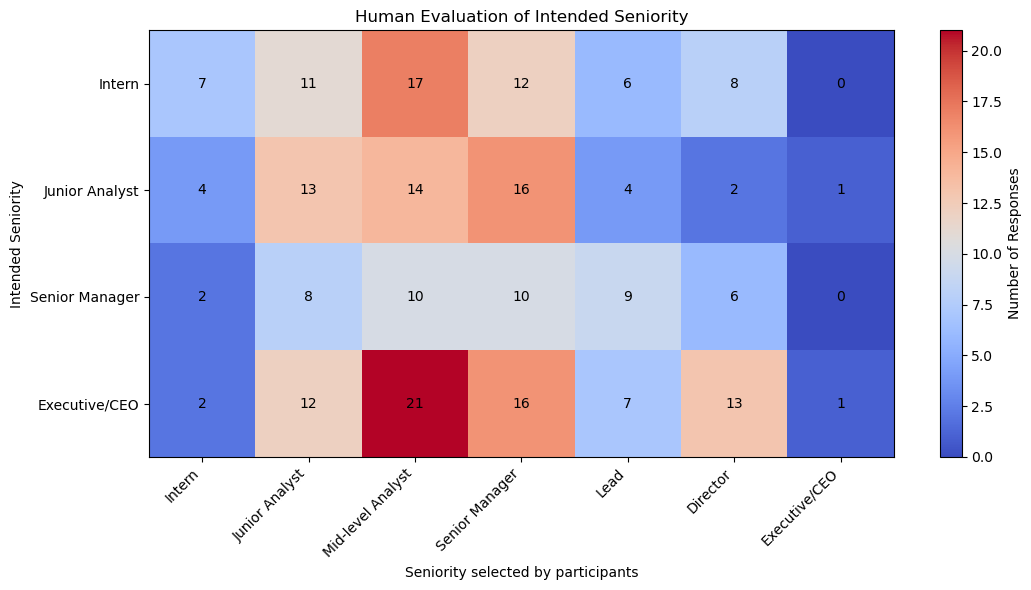

In [18]:
#heatmap

plt.figure(figsize=(11, 6))

plt.imshow(seniority_table.values,aspect="auto", cmap = "coolwarm")

plt.xticks(
    range(len(human_seniority_order)),
    human_seniority_order,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(intended_seniority_order)),
    intended_seniority_order
)

plt.xlabel("Seniority selected by participants")
plt.ylabel("Intended Seniority")
plt.title("Human Evaluation of Intended Seniority")

for row in range(seniority_table.shape[0]):
    for column in range(seniority_table.shape[1]):
        plt.text(
            column,
            row,
            seniority_table.iloc[row, column],
            ha="center",
            va="center"
        )

plt.colorbar(label="Number of Responses")
plt.tight_layout()

plt.show()